# 0.1 Polymarket: Descriptive Analysis

Explores daily **prediction-market win probabilities** for Trump and Harris
over the 2024 US election campaign (5 Jul – 4 Nov 2024).

**Input:** `Data/1_Bronze/Polymarket/polymarket_win_probabilities.csv`


<!-- toc -->
## Contents
- [Win Probabilities Over Time](#win-probabilities-over-time)
- [Trump – Harris Spread](#trump-harris-spread)
- [Probability Around Key Events  (indexed)](#probability-around-key-events-indexed)
- [Event Summary Table](#event-summary-table)


In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
from pathlib import Path

sys.path.insert(0, '../..')
from house_style import *
apply_style()

In [2]:
df = pd.read_csv(
    Path('../../data/1_bronze/polymarket/polymarket_win_probabilities.csv'),
    parse_dates=['date']
).sort_values('date').reset_index(drop=True)

# Limit to campaign period (5 Jul – 4 Nov 2024), consistent with other notebooks
df = df[df['date'] <= '2024-11-04'].reset_index(drop=True)

# 7-day rolling averages
df['trump_7d']  = df['Trump (%)'].rolling(7, min_periods=1).mean()
df['harris_7d'] = df['Harris (%)'].rolling(7, min_periods=1).mean()
df['spread']    = df['Trump (%)'] - df['Harris (%)']   # >0 means Trump leads

print(f"Rows : {len(df)}")
print(f"Range: {df['date'].min().date()}  to  {df['date'].max().date()}")
df.describe().round(1)

Rows : 127
Range: 2024-07-01  to  2024-11-04


,date,Trump (%),Harris (%),trump_7d,harris_7d,spread
count,127,127.0,127.0,127.0,127.0,127.0
mean,2024-09-02 00:00:00,54.9,40.2,55.1,39.4,14.8
min,2024-07-01 00:00:00,44.3,4.4,45.2,4.4,-9.6
25%,2024-08-01 12:00:00,49.3,36.0,49.6,35.9,-0.1
50%,2024-09-02 00:00:00,52.9,45.8,52.2,46.3,7.0
75%,2024-10-03 12:00:00,60.6,49.4,61.8,48.9,27.3
max,2024-11-04 00:00:00,70.5,53.9,67.1,52.3,64.4
std,NaN,6.7,13.2,6.6,13.8,19.2


### Win Probabilities Over Time

Raw daily values (faint) and 7-day rolling average (solid). Shaded area highlights which candidate leads. Dashed lines mark the six key political events.

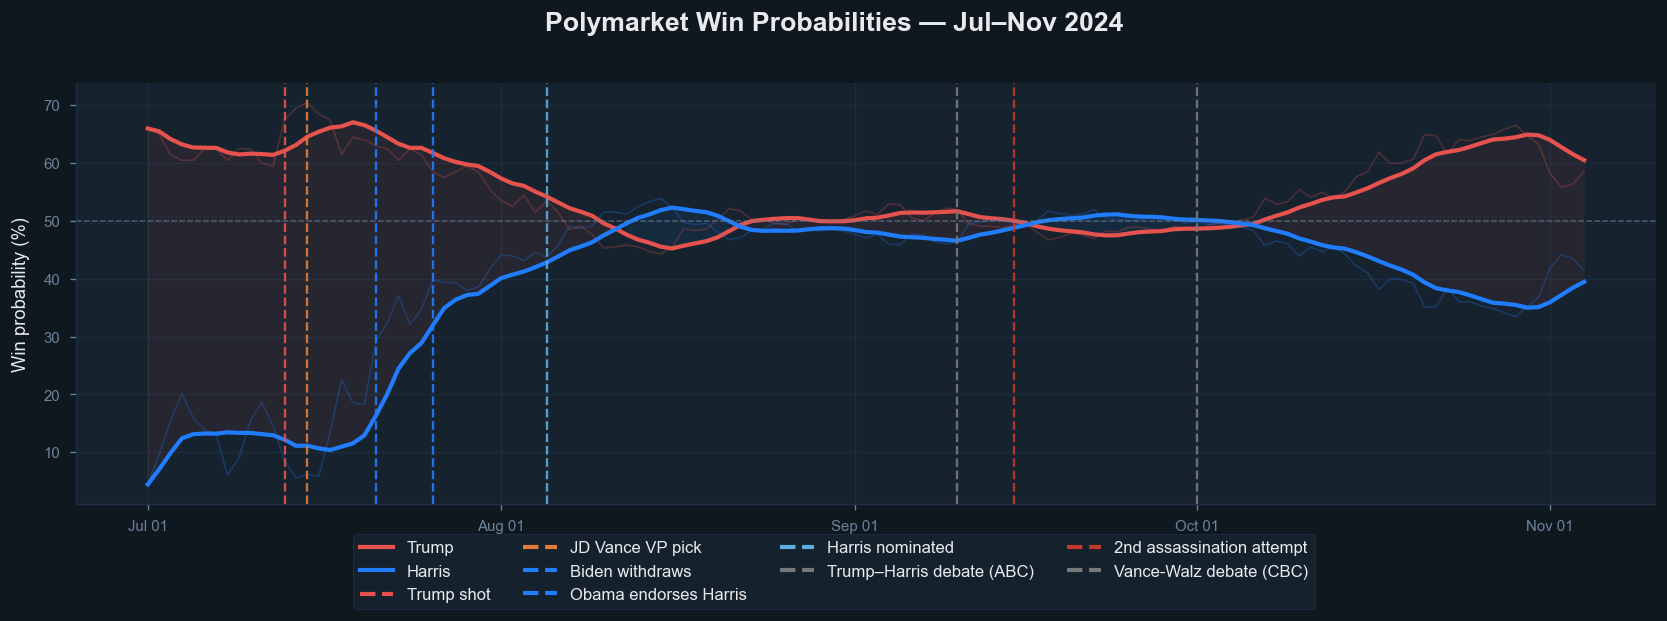

In [3]:
fig, ax = styled_fig(figsize=(14, 5), title='Polymarket Win Probabilities — Jul–Nov 2024')

# Raw daily (faint) + 7-day rolling (solid)
ax.plot(df['date'], df['Trump (%)'],  color=REPUBLICAN, alpha=0.25, linewidth=1)
ax.plot(df['date'], df['trump_7d'],   color=REPUBLICAN, linewidth=2.5, label='Trump (7d MA)')
ax.plot(df['date'], df['Harris (%)'], color=DEMOCRAT,   alpha=0.25, linewidth=1)
ax.plot(df['date'], df['harris_7d'],  color=DEMOCRAT,   linewidth=2.5, label='Harris (7d MA)')
ax.fill_between(df['date'], df['trump_7d'], df['harris_7d'],
                where=df['trump_7d'] >= df['harris_7d'],
                color=REPUBLICAN, alpha=0.08)
ax.fill_between(df['date'], df['trump_7d'], df['harris_7d'],
                where=df['trump_7d'] < df['harris_7d'],
                color=DEMOCRAT, alpha=0.08)
ax.axhline(50, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.6)

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Win probability (%)', grid_axis='y')

data_handles = [
    mlines.Line2D([], [], color=REPUBLICAN, linewidth=2.5, label='Trump'),
    mlines.Line2D([], [], color=DEMOCRAT,   linewidth=2.5, label='Harris'),
]
fig.legend(
    handles=data_handles + event_legend_handles(),
    loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=4, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
    labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95
)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

### Trump – Harris Spread

Positive = Trump leads; negative = Harris leads. Shows how the gap evolved across the campaign.

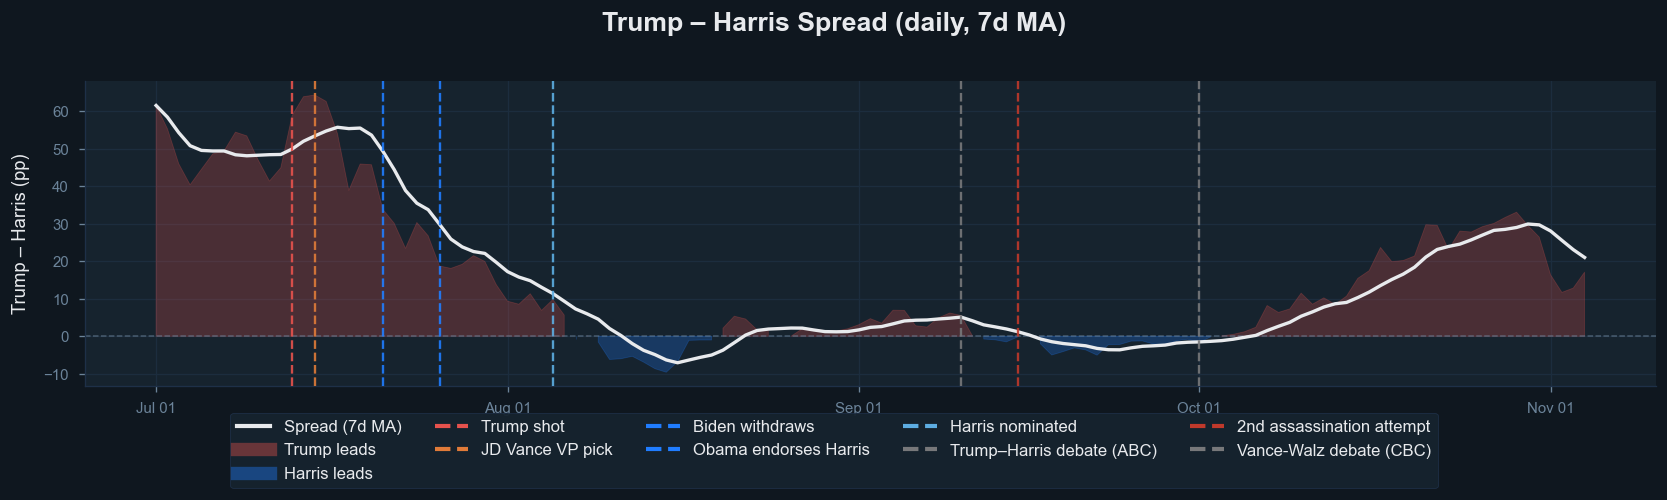

In [4]:
fig, ax = styled_fig(figsize=(14, 4), title='Trump – Harris Spread (daily, 7d MA)')

ax.axhline(0, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.6)
ax.fill_between(df['date'], df['spread'], 0,
                where=df['spread'] >= 0, color=REPUBLICAN, alpha=0.25, label='Trump leads')
ax.fill_between(df['date'], df['spread'], 0,
                where=df['spread'] < 0,  color=DEMOCRAT,   alpha=0.25, label='Harris leads')
spread_7d = df['spread'].rolling(7, min_periods=1).mean()
ax.plot(df['date'], spread_7d, color=TEXT_PRIMARY, linewidth=2, label='Spread (7d MA)')

add_events(ax)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
style_ax(ax, ylabel='Trump – Harris (pp)', grid_axis='y')

fig.legend(
    handles=[
        mlines.Line2D([], [], color=TEXT_PRIMARY, linewidth=2.5, label='Spread (7d MA)'),
        mlines.Line2D([], [], color=REPUBLICAN, linewidth=8, alpha=0.4, label='Trump leads'),
        mlines.Line2D([], [], color=DEMOCRAT,   linewidth=8, alpha=0.4, label='Harris leads'),
    ] + event_legend_handles(),
    loc='lower center', bbox_to_anchor=(0.5, 0.01),
    ncol=5, facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
    labelcolor=TEXT_PRIMARY, fontsize=10, framealpha=0.95
)
plt.tight_layout(rect=[0, 0.14, 1, 1])
plt.show()

### Probability Around Key Events  (indexed)

Each candidate's probability indexed to 100 on the event day, shown over a ±7-day window. Reveals how markets reacted to each political shock.

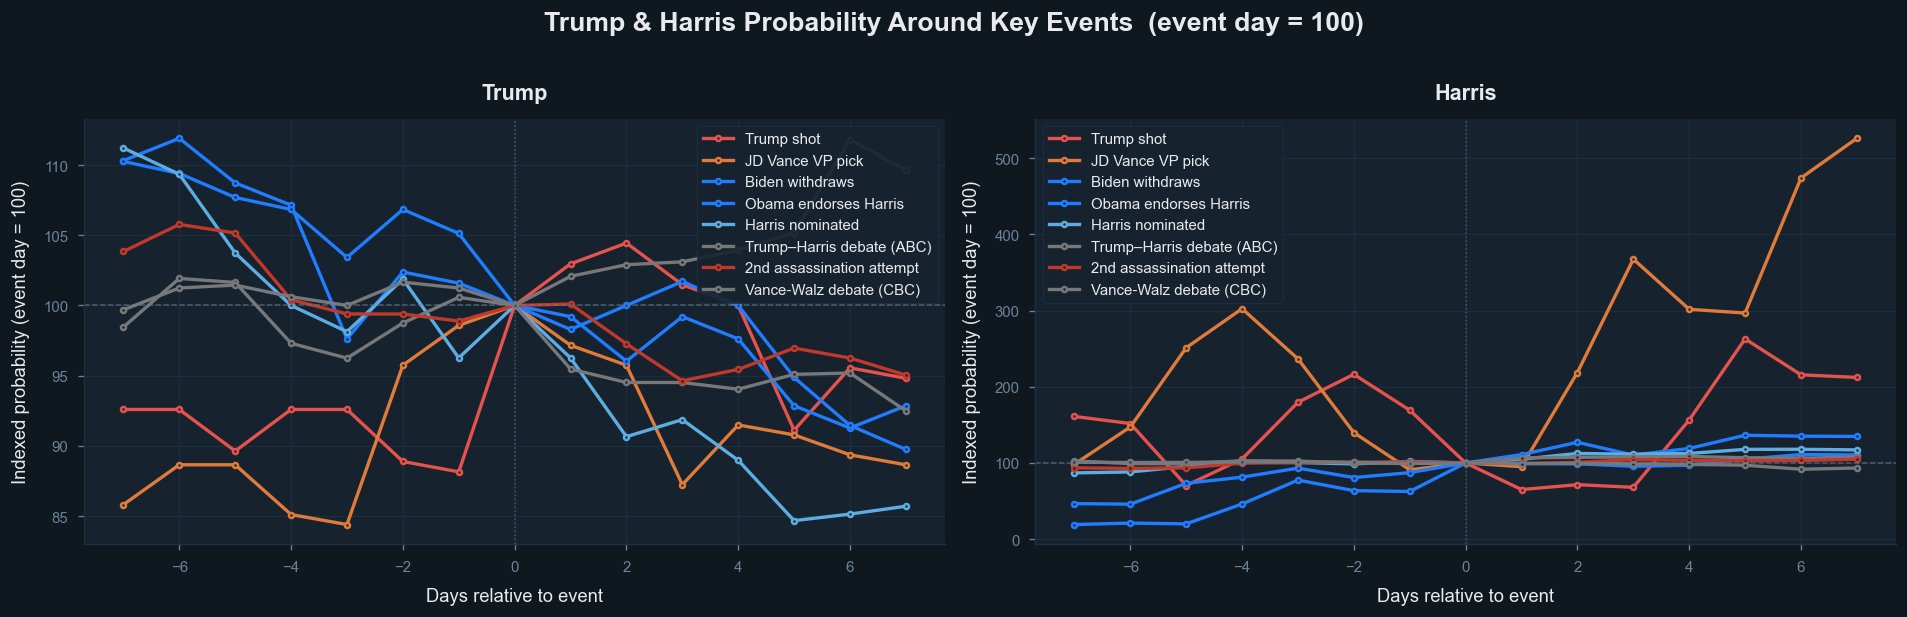

In [5]:
# Win probability in a ±7-day window around each key event, indexed to event day = 100
def index_around(col, event_date_str, days=7):
    ev  = pd.Timestamp(event_date_str)
    win = df[(df['date'] >= ev - pd.Timedelta(days=days)) &
             (df['date'] <= ev + pd.Timedelta(days=days))].copy().reset_index(drop=True)
    base_idx = (win['date'] - ev).abs().idxmin()
    base     = win.loc[base_idx, col]
    if base == 0:
        return None, None
    rel  = (win['date'] - ev).dt.days.values
    vals = (win[col] / base * 100).values
    return rel, vals

fig, axes = styled_fig(nrows=1, ncols=2, figsize=(16, 5),
                       title='Trump & Harris Probability Around Key Events  (event day = 100)')

for ax_i, (col, cand_color, label) in enumerate([
    ('Trump (%)',  REPUBLICAN, 'Trump'),
    ('Harris (%)', DEMOCRAT,   'Harris'),
]):
    ax = axes[ax_i]
    for ev_lbl, ev_date, ev_color in EVENTS:
        rel, vals = index_around(col, ev_date)
        if rel is None:
            continue
        ax.plot(rel, vals, color=ev_color, linewidth=2, label=ev_lbl,
                marker='o', markersize=3,
                markerfacecolor=BG_PANEL, markeredgecolor=ev_color, markeredgewidth=1.5)
    ax.axhline(100, color=TEXT_MUTED, linestyle='--', linewidth=0.9, alpha=0.6)
    ax.axvline(0,   color=TEXT_MUTED, linestyle=':',  linewidth=0.9, alpha=0.5)
    style_ax(ax, xlabel='Days relative to event',
             ylabel='Indexed probability (event day = 100)', title=label)
    ax.legend(facecolor=BG_PANEL, edgecolor=SPINE_COLOR,
              labelcolor=TEXT_PRIMARY, fontsize=9)

plt.tight_layout()
plt.show()

### Event Summary Table

Win probability for each candidate the day before and the day after each key event.

In [6]:
def prob_on(offset, date_str):
    ev     = pd.Timestamp(date_str)
    target = ev + pd.Timedelta(days=offset)
    match  = df[df['date'] >= target] if offset >= 0 else df[df['date'] <= target]
    if match.empty:
        return None, None
    row = match.iloc[0] if offset >= 0 else match.iloc[-1]
    return round(row['Trump (%)'], 1), round(row['Harris (%)'], 1)

rows = []
for lbl, date, _ in EVENTS:
    t_m1, h_m1 = prob_on(-1, date)
    t_0,  h_0  = prob_on( 0, date)
    t_p1, h_p1 = prob_on(+1, date)
    rows.append({
        'Event'         : lbl,
        'Date'          : date,
        'Trump day −1'  : t_m1,
        'Harris day −1' : h_m1,
        'Trump day 0'   : t_0,
        'Harris day 0'  : h_0,
        'Trump day +1'  : t_p1,
        'Harris day +1' : h_p1,
        'Δ Trump'       : round(t_p1 - t_m1, 1) if (t_m1 and t_p1) else None,
        'Δ Harris'      : round(h_p1 - h_m1, 1) if (h_m1 and h_p1) else None,
    })

summary = pd.DataFrame(rows).set_index(['Event', 'Date'])

def color_cell(val, col):
    if pd.isna(val): return ''
    if 'Trump'  in col: return f'color: {REPUBLICAN}'
    if 'Harris' in col: return f'color: {DEMOCRAT}'
    return ''

delta_cols = ['Δ Trump', 'Δ Harris']
value_cols = [c for c in summary.columns if c not in delta_cols]

styled = (summary.style
    .format('{:.1f}%',  subset=value_cols, na_rep='—')
    .format('{:+.1f}%', subset=delta_cols, na_rep='—'))

for col in summary.columns:
    styled = styled.map(lambda v, c=col: color_cell(v, c), subset=[col])

styled.set_caption('Polymarket probabilities — day before, event day, and day after each key event')

,,Trump day −1,Harris day −1,Trump day 0,Harris day 0,Trump day +1,Harris day +1,Δ Trump,Δ Harris
Event,Date,,,,,,,,
Trump shot,2024-07-13,59.5%,14.6%,67.5%,8.6%,69.5%,5.6%,+10.0%,-9.0%
JD Vance VP pick,2024-07-15,69.5%,5.6%,70.5%,6.2%,68.5%,5.8%,-1.0%,+0.2%
Biden withdraws,2024-07-21,64.0%,18.2%,63.0%,29.2%,62.5%,32.4%,-1.5%,+14.2%
Obama endorses Harris,2024-07-26,61.5%,34.7%,58.5%,39.8%,57.5%,39.4%,-4.0%,+4.7%
Harris nominated,2024-08-05,51.5%,44.6%,53.5%,43.7%,51.5%,45.8%,+0.0%,+1.2%
Trump–Harris debate (ABC),2024-09-10,52.2%,46.0%,52.0%,46.4%,49.6%,49.4%,-2.6%,+3.4%
2nd assassination attempt,2024-09-15,48.8%,50.4%,49.4%,49.6%,49.4%,49.2%,+0.6%,-1.2%
Vance-Walz debate (CBC),2024-10-01,48.8%,49.6%,48.2%,49.8%,49.2%,49.4%,+0.4%,-0.2%
